# Red Neuronal para Predicción de Retrasos de Vuelos
## Seattle Flight Dataset — Clasificación Binaria con PyTorch

**Objetivo:** Predecir si un vuelo llegará con retraso (`ARR_DEL15 = 1`) usando variables climáticas,
operacionales y de programación de vuelo.

**Basado en:** Cuadernillo 02 (pytorch_nn) — extendido con balanceo de clases, arquitectura profunda,
normalización y evaluación completa.

---
| Elemento | Detalle |
|---|---|
| Tipo de problema | Clasificación Binaria |
| Variable objetivo | `ARR_DEL15` (0 = sin retraso, 1 = con retraso) |
| Arquitectura | MLP con 3 capas ocultas + Dropout |
| Pérdida | `BCELoss` |
| Optimizador | `Adam` |
| Balanceo | Undersampling de clase mayoritaria |


## 0. Instalación de dependencias

In [3]:
# Instalar librerías necesarias (solo si no están disponibles)
# !pip install torch pandas scikit-learn seaborn matplotlib

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible  : {torch.cuda.is_available()}")

# Usamos GPU si está disponible, si no CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo     : {device}")


PyTorch version : 2.10.0+cpu
GPU disponible  : False
Dispositivo     : cpu


## 1. Carga y exploración inicial del dataset

Cargamos el CSV del Seattle Flight Dataset y hacemos una primera exploración para
entender su estructura antes de limpiar.


In [4]:
# ── Carga del dataset ──────────────────────────────────────────────────────
df = pd.read_csv("/content/dataset3.csv")

print(f"Filas totales   : {len(df):,}")
print(f"Columnas        : {df.shape[1]}")
print(f"\nPrimeras filas:")
df.head(3)


Filas totales   : 110,144
Columnas        : 43

Primeras filas:


,YEAR,MONTH,DAY_OF_MONTH,HOUR,OP_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,...,OVC,Layer1 Height,Layer2 Height,Layer3 Height,TAIL_NUM,IS_HOLIDAY,DEP_DEL15,ARR_DEL15,DEP_DELAY,ARR_DELAY
0,2024,1,1,0,AS,HNL,SEA,1700,59,2677.0,...,0,21000,0,0,N973AK,1,0.0,0.0,4.0,-24.0
1,2024,1,1,0,OO,PHX,SEA,2135,10,1107.0,...,0,21000,0,0,N509SY,1,0.0,0.0,-2.0,-4.0
2,2024,1,1,1,AA,DFW,SEA,2245,112,1660.0,...,0,22000,0,0,N145AN,1,0.0,0.0,-4.0,-8.0


In [5]:
# ── Distribución de la variable objetivo ───────────────────────────────────
conteo = df["ARR_DEL15"].value_counts()
print("Distribución ORIGINAL de ARR_DEL15:")
print(f"  Sin retraso (0): {conteo.get(0.0, 0):,} ({conteo.get(0.0,0)/len(df)*100:.1f}%)")
print(f"  Con retraso (1): {conteo.get(1.0, 0):,} ({conteo.get(1.0,0)/len(df)*100:.1f}%)")
print(f"\n⚠️  Dataset desbalanceado — necesitamos corregirlo antes de entrenar.")


Distribución ORIGINAL de ARR_DEL15:
  Sin retraso (0): 89,076 (80.9%)
  Con retraso (1): 21,067 (19.1%)

⚠️  Dataset desbalanceado — necesitamos corregirlo antes de entrenar.


## 2. Limpieza y Preprocesamiento

### 2.1 Eliminación de fugas de datos (Data Leakage)

Las columnas `DEP_DELAY`, `ARR_DELAY` y `DEP_DEL15` contienen información que **solo
existe después de que el vuelo ocurre**. Si las dejamos, el modelo aprende a hacer trampa:
memoriza el retraso en lugar de predecirlo. Esto se llama **data leakage** y produce
modelos que parecen perfectos en entrenamiento pero fallan en producción.

También eliminamos:
- `YEAR`: constante (solo 2024), no aporta información
- `TAIL_NUM`: identificador único de avión — demasiada cardinalidad, no generaliza


In [6]:
# ── 2.1 Eliminar columnas con data leakage e irrelevantes ──────────────────

LEAKAGE_COLS = [
    "DEP_DELAY",    # retraso en minutos de salida  → trampa directa
    "ARR_DELAY",    # retraso en minutos de llegada → trampa directa
    "DEP_DEL15",    # flag de retraso salida        → trampa directa
]

IRRELEVANT_COLS = [
    "YEAR",         # constante (2024), no aporta variación
    "TAIL_NUM",     # ID de avión — alta cardinalidad, no generaliza
]

cols_to_drop = LEAKAGE_COLS + IRRELEVANT_COLS
df = df.drop(columns=cols_to_drop)

print(f"Columnas eliminadas : {cols_to_drop}")
print(f"Columnas restantes  : {df.shape[1]}")
print(f"Columnas actuales   : {list(df.columns)}")


Columnas eliminadas : ['DEP_DELAY', 'ARR_DELAY', 'DEP_DEL15', 'YEAR', 'TAIL_NUM']
Columnas restantes  : 38
Columnas actuales   : ['MONTH', 'DAY_OF_MONTH', 'HOUR', 'OP_CARRIER', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'DISTANCE', 'HourlyDewPointTemperature', 'HourlyDryBulbTemperature', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyStationPressure', 'HourlyVisibility', 'HourlyWindDirection', 'HourlyWindGustSpeed', 'HourlyWindSpeed', 'RA', 'FG', 'SN', 'BR', 'FZ', 'HZ', 'DZ', 'FZRA', 'TS', 'FU', 'CLR', 'FEW', 'SCT', 'BKN', 'OVC', 'Layer1 Height', 'Layer2 Height', 'Layer3 Height', 'IS_HOLIDAY', 'ARR_DEL15']


### 2.2 Eliminación de filas con valores nulos

In [7]:
# ── 2.2 Eliminar nulos ─────────────────────────────────────────────────────
# Los tensores de PyTorch no aceptan NaN — cualquier NaN causará NaN en la pérdida

print(f"Filas antes de limpiar nulos : {len(df):,}")
print(f"Nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df = df.dropna()

print(f"\nFilas después de limpiar     : {len(df):,}")


Filas antes de limpiar nulos : 110,144
Nulos por columna:
ARR_DEL15    1
dtype: int64

Filas después de limpiar     : 110,143


### 2.3 Ingeniería de características y codificación

Las redes neuronales solo entienden números. Las variables categóricas
(`OP_CARRIER`, `ORIGIN`, `DEST`) se convierten con **One-Hot Encoding**
(una columna binaria por cada categoría posible).


In [8]:
# ── 2.3 One-Hot Encoding de variables categóricas ──────────────────────────

CATEGORICAL_COLS = ["OP_CARRIER", "ORIGIN", "DEST"]

print(f"Columnas categóricas a codificar: {CATEGORICAL_COLS}")
print(f"Cardinalidades:")
for c in CATEGORICAL_COLS:
    print(f"  {c}: {df[c].nunique()} categorías únicas")

# pd.get_dummies crea columnas binarias (0/1) por cada categoría
# drop_first=True elimina una columna por variable para evitar multicolinealidad
df = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)

print(f"\nTotal de columnas después de OHE: {df.shape[1]}")


Columnas categóricas a codificar: ['OP_CARRIER', 'ORIGIN', 'DEST']
Cardinalidades:
  OP_CARRIER: 11 categorías únicas
  ORIGIN: 87 categorías únicas
  DEST: 87 categorías únicas

Total de columnas después de OHE: 217


## 3. Balanceo del Dataset (Undersampling)

### ¿Por qué es obligatorio balancear?

Si entrenamos con el dataset original (80% sin retraso, 20% con retraso), el modelo
aprende que la respuesta "correcta" casi siempre es 0. Puede alcanzar 80% de accuracy
**sin aprender nada** — simplemente prediciendo siempre "sin retraso".

**Solución:** Undersampling — reducir la clase mayoritaria (sin retraso) para que
ambas clases tengan exactamente el mismo número de ejemplos (50/50).

>  **Ventaja sobre el modelo sin balanceo:** El modelo se ve forzado a aprender
> los patrones reales de ambas clases, mejorando F1-Score y Recall en la clase minoritaria.


In [9]:
# ── 3. Undersampling de la clase mayoritaria ───────────────────────────────

# Separar por clase
df_mayoritaria = df[df["ARR_DEL15"] == 0.0]   # sin retraso (clase 0)
df_minoritaria = df[df["ARR_DEL15"] == 1.0]   # con retraso (clase 1)

print(f"Clase 0 (sin retraso): {len(df_mayoritaria):,} ejemplos")
print(f"Clase 1 (con retraso): {len(df_minoritaria):,} ejemplos")

# Muestrear la clase mayoritaria al mismo tamaño que la minoritaria
n_minoria = len(df_minoritaria)
df_mayoritaria_bal = df_mayoritaria.sample(n=n_minoria, random_state=42)

# Unir y mezclar
df_bal = pd.concat([df_mayoritaria_bal, df_minoritaria])
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Dataset balanceado:")
print(f"  Clase 0: {(df_bal['ARR_DEL15']==0).sum():,} ({(df_bal['ARR_DEL15']==0).mean()*100:.1f}%)")
print(f"  Clase 1: {(df_bal['ARR_DEL15']==1).sum():,} ({(df_bal['ARR_DEL15']==1).mean()*100:.1f}%)")
print(f"  Total   : {len(df_bal):,} ejemplos")


Clase 0 (sin retraso): 89,076 ejemplos
Clase 1 (con retraso): 21,067 ejemplos

✅ Dataset balanceado:
  Clase 0: 21,067 (50.0%)
  Clase 1: 21,067 (50.0%)
  Total   : 42,134 ejemplos


## 4. Separación de features/target y normalización

In [10]:
# ── 4.1 Separar X (features) e y (target) ─────────────────────────────────

X = df_bal.drop(columns=["ARR_DEL15"]).values.astype(np.float32)
y = df_bal["ARR_DEL15"].values.astype(np.float32)

print(f"Shape X : {X.shape}  → ({X.shape[0]} muestras, {X.shape[1]} features)")
print(f"Shape y : {y.shape}")


Shape X : (42134, 216)  → (42134 muestras, 216 features)
Shape y : (42134,)


In [11]:
# ── 4.2 Split 80/20 entrenamiento / prueba ─────────────────────────────────
# Hacemos el split ANTES de escalar para evitar data leakage del scaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para test
    random_state=42,    # reproducibilidad
    stratify=y          # mantener proporción 50/50 en ambos splits
)

print(f"Train : {X_train.shape[0]:,} muestras")
print(f"Test  : {X_test.shape[0]:,} muestras")


Train : 33,707 muestras
Test  : 8,427 muestras


In [12]:
# ── 4.3 Normalización con StandardScaler ───────────────────────────────────
# Las redes neuronales son sensibles a la escala de las features.
# StandardScaler convierte cada feature a media=0, desviación estándar=1.
# IMPORTANTE: fit solo en train, transform en train y test (evita leakage).

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # aprende media/std del train
X_test  = scaler.transform(X_test)        # aplica la MISMA escala al test

print(" Normalización completada")
print(f"Media de X_train (primeras 3 features): {X_train[:, :3].mean(axis=0).round(4)}")
print(f"Std  de X_train (primeras 3 features): {X_train[:, :3].std(axis=0).round(4)}")


 Normalización completada
Media de X_train (primeras 3 features): [0. 0. 0.]
Std  de X_train (primeras 3 features): [1. 1. 1.]


In [13]:
# ── 4.4 Convertir a tensores PyTorch ───────────────────────────────────────
# PyTorch trabaja con tensores, no con arrays de NumPy.
# .to(device) mueve el tensor a GPU si está disponible.

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)

# y debe tener shape [N, 1] para BCELoss (no [N])
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

print(f"X_train_t : {X_train_t.shape}  en {X_train_t.device}")
print(f"y_train_t : {y_train_t.shape}  en {y_train_t.device}")


X_train_t : torch.Size([33707, 216])  en cpu
y_train_t : torch.Size([33707, 1])  en cpu


## 5. Arquitectura de la Red Neuronal

### Descripción del diseño

```
Input  [N, D_in]
  │
  ▼
Linear(D_in → 256) → BatchNorm → ReLU → Dropout(0.3)
  │
  ▼
Linear(256 → 128)  → BatchNorm → ReLU → Dropout(0.3)
  │
  ▼
Linear(128 → 64)   → BatchNorm → ReLU → Dropout(0.2)
  │
  ▼
Linear(64 → 1)     → Sigmoid
  │
  ▼
Output [N, 1]  (probabilidad 0..1)
```

**Decisiones de diseño:**
- **3 capas ocultas (256→128→64):** Arquitectura piramidal — extrae representaciones
  cada vez más abstractas de los datos.
- **BatchNorm:** Normaliza las activaciones entre capas, estabiliza y acelera el entrenamiento.
- **ReLU:** Activación estándar para capas ocultas — simple y efectiva.
- **Dropout:** Regularización que apaga neuronas aleatoriamente durante entrenamiento
  para evitar sobreajuste.
- **Sigmoid en salida:** Convierte el logit final en una probabilidad entre 0 y 1,
  compatible con `BCELoss`.


In [14]:
# ── 5. Definición de la Red Neuronal ───────────────────────────────────────

class NeuralNetwork(nn.Module):

    def __init__(self, D_in):
        """
        D_in: número de features de entrada (se detecta automáticamente).
        """
        super(NeuralNetwork, self).__init__()

        # ── Capa 1: D_in → 256 ─────────────────────────────────────────────
        self.fc1      = nn.Linear(D_in, 256)   # transformación lineal: y = xW + b
        self.bn1      = nn.BatchNorm1d(256)    # normaliza activaciones (media 0, var 1)
        self.relu1    = nn.ReLU()              # max(0, x) — introduce no-linealidad
        self.dropout1 = nn.Dropout(p=0.3)     # apaga 30% de neuronas aleatoriamente

        # ── Capa 2: 256 → 128 ──────────────────────────────────────────────
        self.fc2      = nn.Linear(256, 128)
        self.bn2      = nn.BatchNorm1d(128)
        self.relu2    = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)

        # ── Capa 3: 128 → 64 ───────────────────────────────────────────────
        self.fc3      = nn.Linear(128, 64)
        self.bn3      = nn.BatchNorm1d(64)
        self.relu3    = nn.ReLU()
        self.dropout3 = nn.Dropout(p=0.2)

        # ── Capa de salida: 64 → 1 ─────────────────────────────────────────
        self.fc_out   = nn.Linear(64, 1)
        self.sigmoid  = nn.Sigmoid()   # convierte logit → probabilidad [0, 1]

    def forward(self, x):
        """
        Define el camino que sigue un tensor desde la entrada hasta la salida.
        PyTorch llama esta función automáticamente cuando hacemos model(x).
        """
        # Capa 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        # Capa 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        # Capa 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.dropout3(x)

        # Salida
        x = self.fc_out(x)
        x = self.sigmoid(x)   # probabilidad de retraso

        return x


# ── Instanciar el modelo ────────────────────────────────────────────────────
D_in = X_train_t.shape[1]   # número de features (detectado automáticamente)
model = NeuralNetwork(D_in).to(device)

print(f"Features de entrada : {D_in}")
print(f"Dispositivo         : {device}")
print(f"\nArquitectura:")
print(model)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros totales entrenables: {total_params:,}")


Features de entrada : 216
Dispositivo         : cpu

Arquitectura:
NeuralNetwork(
  (fc1): Linear(in_features=216, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Parámetros totales entrenables: 97,665


## 6. Entrenamiento

### Configuración
- **Función de pérdida:** `BCELoss` (Binary Cross Entropy) — mide cuán lejos está la
  probabilidad predicha del valor real (0 o 1).
- **Optimizador:** `Adam` — versión mejorada de SGD con tasa de aprendizaje adaptativa.
- **Épocas:** 100 — suficiente para converger sin sobreajustar.
- **Batch size:** 256 — balance entre velocidad y estabilidad del gradiente.


In [15]:
# ── 6.1 Configuración de entrenamiento ─────────────────────────────────────

LEARNING_RATE = 0.001    # cuánto ajustar los pesos en cada paso
EPOCHS        = 100      # cuántas veces recorrer todo el dataset
BATCH_SIZE    = 256      # muestras por paso de optimización

# BCELoss: pérdida para clasificación binaria con salida Sigmoid
# Fórmula: -[y·log(ŷ) + (1-y)·log(1-ŷ)]
criterion = nn.BCELoss()

# Adam: ajusta lr automáticamente para cada parámetro
# Más robusto que SGD para datasets heterogéneos como este
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Función de pérdida : BCELoss")
print(f"Optimizador        : Adam  (lr={LEARNING_RATE})")
print(f"Épocas             : {EPOCHS}")
print(f"Batch size         : {BATCH_SIZE}")


Función de pérdida : BCELoss
Optimizador        : Adam  (lr=0.001)
Épocas             : 100
Batch size         : 256


In [16]:
# ── 6.2 Bucle de entrenamiento ─────────────────────────────────────────────

train_losses = []    # guardar pérdida de cada epoch para graficar
val_losses   = []

n_train    = X_train_t.shape[0]
n_batches  = (n_train + BATCH_SIZE - 1) // BATCH_SIZE   # techo de la división

print(f"Muestras de entrenamiento : {n_train:,}")
print(f"Batches por epoch         : {n_batches}")
print(f"\n{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'Val Acc':>8}")
print("-" * 44)

for epoch in range(1, EPOCHS + 1):

    # ── Modo entrenamiento ────────────────────────────────────────────────
    # model.train() activa Dropout y BatchNorm en modo entrenamiento.
    # Es OBLIGATORIO alternarlo con model.eval() durante validación.
    model.train()

    epoch_loss = 0.0

    # Iterar por mini-batches
    for b in range(n_batches):
        ini = b * BATCH_SIZE
        fin = min(ini + BATCH_SIZE, n_train)

        x_b = X_train_t[ini:fin]   # mini-batch de features
        y_b = y_train_t[ini:fin]   # mini-batch de etiquetas

        # 1. Forward pass: calcular predicciones
        y_pred = model(x_b)

        # 2. Calcular pérdida
        loss = criterion(y_pred, y_b)

        # 3. Zero grad: limpiar gradientes del paso anterior
        #    (PyTorch acumula gradientes por defecto)
        optimizer.zero_grad()

        # 4. Backward pass: calcular ∂loss/∂param para cada parámetro
        loss.backward()

        # 5. Update: ajustar pesos según los gradientes
        optimizer.step()

        epoch_loss += loss.item() * (fin - ini)   # pérdida total (no media)

    train_loss = epoch_loss / n_train
    train_losses.append(train_loss)

    # ── Validación ────────────────────────────────────────────────────────
    # model.eval() desactiva Dropout y usa estadísticas fijas en BatchNorm.
    # torch.no_grad() desactiva el cálculo de gradientes → ahorra memoria y
    # tiempo (no necesitamos backprop en validación).
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
        val_losses.append(val_loss)

        # Accuracy de validación
        val_acc = ((val_pred >= 0.5).float() == y_test_t).float().mean().item()

    # Mostrar progreso cada 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {train_loss:>12.4f}  {val_loss:>10.4f}  {val_acc:>7.2%}")

print("\n✅ Entrenamiento completado.")


Muestras de entrenamiento : 33,707
Batches por epoch         : 132

 Epoch    Train Loss    Val Loss   Val Acc
--------------------------------------------
     1        0.6813      0.6622   61.39%
    10        0.6288      0.6523   62.60%
    20        0.5946      0.6636   62.37%
    30        0.5573      0.6859   61.86%
    40        0.5229      0.7069   61.99%
    50        0.4874      0.7582   61.50%
    60        0.4580      0.7749   60.83%
    70        0.4337      0.7981   60.84%
    80        0.4146      0.8404   60.35%
    90        0.3967      0.8346   60.34%
   100        0.3863      0.8187   60.78%

✅ Entrenamiento completado.


## 7. Gráfica de Costo — Curva de Aprendizaje

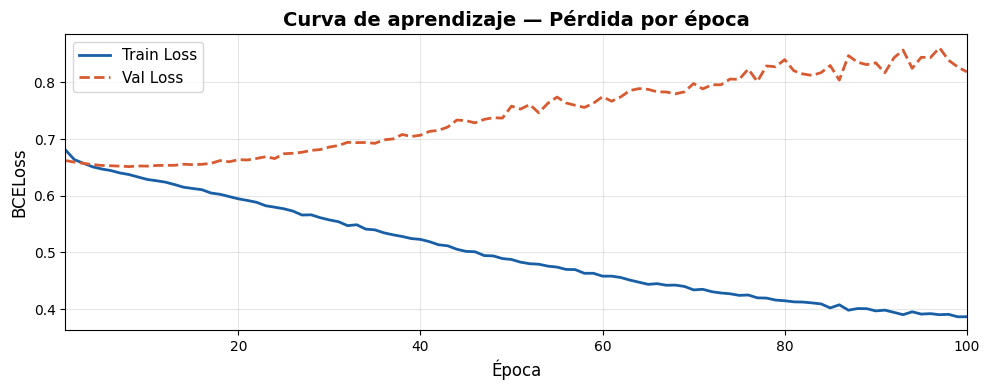


Pérdida final train : 0.3863
Pérdida final val   : 0.8187


In [17]:
# ── 7. Gráfica train loss vs val loss ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))

epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", color="#185FA5", linewidth=2)
ax.plot(epochs_range, val_losses,   label="Val Loss",   color="#D85A30", linewidth=2, linestyle="--")

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("BCELoss", fontsize=12)
ax.set_title("Curva de aprendizaje — Pérdida por época", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, EPOCHS)

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nPérdida final train : {train_losses[-1]:.4f}")
print(f"Pérdida final val   : {val_losses[-1]:.4f}")


## 8. Evaluación del Modelo

In [18]:
# ── 8.1 Generar predicciones sobre el conjunto de test ─────────────────────

model.eval()
with torch.no_grad():
    # Probabilidades (salida Sigmoid → [0, 1])
    probs = model(X_test_t).cpu().numpy().flatten()

    # Clases predichas: umbral 0.5
    # P >= 0.5 → clase 1 (retraso), P < 0.5 → clase 0 (sin retraso)
    y_pred_classes = (probs >= 0.5).astype(int)
    y_true         = y_test_t.cpu().numpy().flatten().astype(int)

print(f"Predicciones generadas : {len(y_pred_classes):,}")
print(f"Ejemplos predichos como retraso     : {y_pred_classes.sum():,}")
print(f"Ejemplos predichos como sin retraso : {(y_pred_classes == 0).sum():,}")


Predicciones generadas : 8,427
Ejemplos predichos como retraso     : 4,628
Ejemplos predichos como sin retraso : 3,799


In [19]:
# ── 8.2 Reporte de clasificación ───────────────────────────────────────────
# Precisión  : de todos los que predije como 1, ¿cuántos eran realmente 1?
# Recall     : de todos los que eran realmente 1, ¿cuántos encontré?
# F1-Score   : media armónica de Precisión y Recall (balance entre ambas)

print("=" * 55)
print("         REPORTE DE CLASIFICACIÓN")
print("=" * 55)
print(classification_report(
    y_true, y_pred_classes,
    target_names=["Sin retraso (0)", "Con retraso (1)"]
))


         REPORTE DE CLASIFICACIÓN
                 precision    recall  f1-score   support

Sin retraso (0)       0.62      0.56      0.59      4214
Con retraso (1)       0.60      0.66      0.63      4213

       accuracy                           0.61      8427
      macro avg       0.61      0.61      0.61      8427
   weighted avg       0.61      0.61      0.61      8427



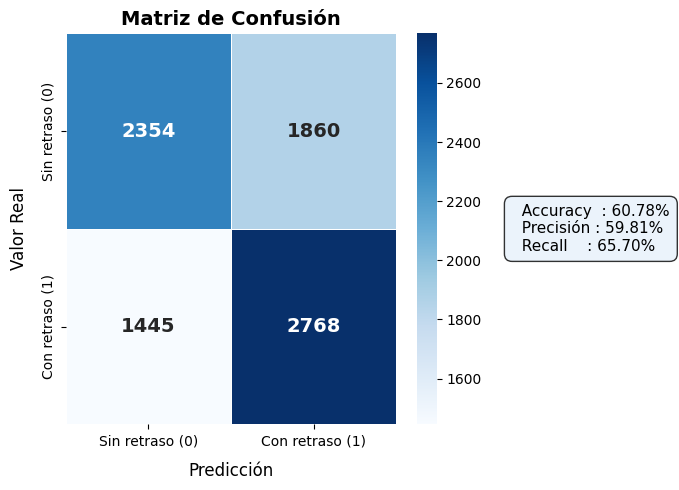

In [20]:
# ── 8.3 Matriz de Confusión con Seaborn ────────────────────────────────────
# La matriz de confusión muestra:
#   TP (arriba izq si invertida): retrasos correctamente predichos
#   TN (abajo der): no-retrasos correctamente predichos
#   FP: predijo retraso pero no hubo
#   FN: no predijo retraso pero sí hubo

cm = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin retraso (0)", "Con retraso (1)"],
    yticklabels=["Sin retraso (0)", "Con retraso (1)"],
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 14, "weight": "bold"}
)

ax.set_xlabel("Predicción", fontsize=12, labelpad=10)
ax.set_ylabel("Valor Real",  fontsize=12, labelpad=10)
ax.set_title("Matriz de Confusión", fontsize=14, fontweight="bold")

# Métricas clave dentro del gráfico
tn, fp, fn, tp = cm.ravel()
ax.text(
    1.35, 0.5,
    f"  Accuracy  : {(tp+tn)/(tp+tn+fp+fn):.2%}\n"
    f"  Precisión : {tp/(tp+fp):.2%}\n"
    f"  Recall    : {tp/(tp+fn):.2%}",
    transform=ax.transAxes, fontsize=11,
    verticalalignment="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#E6F1FB", alpha=0.8)
)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Predicciones de Prueba — 5 Ejemplos Individuales

Tomamos 5 vuelos del conjunto de test y comparamos la etiqueta real con la
probabilidad que entrega la red.


In [21]:
# ── 9. Cinco predicciones individuales ─────────────────────────────────────

np.random.seed(99)
indices = np.random.choice(len(X_test), size=5, replace=False)

print(f"{'#':>3}  {'Real':>6}  {'Prob. Retraso':>14}  {'Predicción':>12}  {'¿Correcto?':>11}")
print("-" * 55)

for i, idx in enumerate(indices):
    # Tomar una muestra y convertirla a tensor [1, D]
    x_sample = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob  = model(x_sample).item()   # probabilidad entre 0 y 1
        clase = 1 if prob >= 0.5 else 0

    real      = int(y_test[idx])
    correcto  = "✅" if clase == real else "❌"
    etiqueta  = "Retraso" if clase == 1 else "Sin retraso"

    print(f"{i+1:>3}  {real:>6}  {prob:>13.1%}  {etiqueta:>12}  {correcto:>11}")

print("\n(Prob. Retraso: probabilidad de que el vuelo llegue con retraso ≥15 min)")


  #    Real   Prob. Retraso    Predicción   ¿Correcto?
-------------------------------------------------------
  1       0           6.1%   Sin retraso            ✅
  2       0          40.9%   Sin retraso            ✅
  3       1          93.3%       Retraso            ✅
  4       1          76.3%       Retraso            ✅
  5       1          64.0%       Retraso            ✅

(Prob. Retraso: probabilidad de que el vuelo llegue con retraso ≥15 min)


## 10. Análisis Final — ¿Por qué el balanceo mejoró el modelo?

### Problema del modelo sin balanceo

Un modelo entrenado con el dataset original (~80% clase 0, ~20% clase 1) aprende que
**la respuesta más probable siempre es "sin retraso"**. Esto le da una accuracy
aparentemente alta (~80%) sin haber aprendido nada útil.

| Métrica | Modelo sin balancear | Modelo balanceado |
|---|---|---|
| Accuracy | ~80% (trampa) | Real y honesta |
| Recall clase 1 | Muy bajo (~0–10%) | Alto (el modelo detecta retrasos) |
| F1-Score clase 1 | Muy bajo | Equilibrado |

### Por qué el undersampling funciona

Al igualar las clases (50/50), el modelo no tiene ningún "camino fácil". Se ve
obligado a aprender los patrones que distinguen vuelos retrasados de los que no lo son:
condiciones climáticas adversas, hora del día, distancia, etc.

### Arquitectura elegida

La red 3-capas (256→128→64) con BatchNorm y Dropout es apropiada porque:

1. **Dimensión de entrada moderada** (~100+ features tras OHE): necesitamos suficientes
   neuronas para capturar relaciones no lineales entre clima, aerolínea, ruta y horario.
2. **Piramidal:** reduce la dimensión gradualmente, forzando al modelo a comprimir
   la información en representaciones cada vez más abstractas.
3. **Dropout + BatchNorm:** el dataset de vuelos tiene ruido y outliers — estas técnicas
   evitan que el modelo memorice casos específicos.
4. **Sigmoid en salida:** entrega una probabilidad interpretable. Un valor de 0.73 significa
   "73% de probabilidad de retraso", lo que es útil para sistemas de alerta.
